# Deep Learning for Time Series Forecasting

Deep learning models can capture **complex non-linear temporal patterns**, **long-range dependencies**, and **multivariate interactions** that classical and shallow ML models struggle with.

## Overview of Architectures

| Model | Key Idea | Best For |
|-------|----------|----------|
| RNN | Recurrent hidden state | Short sequences |
| LSTM | Gated memory cells | Long-range dependencies |
| GRU | Simplified gating | Faster than LSTM |
| TCN | Dilated causal convolutions | Parallelisable, long context |
| N-BEATS | Basis expansion, no recurrence | Univariate, interpretable |
| N-HiTS | Hierarchical interpolation | Multi-horizon, efficient |
| TFT | Transformer + LSTM + attention | Multi-variate, interpretable |
| PatchTST | Patched Transformer | Long sequences |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# AirPassengers
from statsmodels.datasets import get_rdataset
data = get_rdataset('AirPassengers').data
data.index = pd.date_range(start='1949-01', periods=len(data), freq='MS')
series = data['value'].values.astype(np.float32)

# Normalise
mu, sigma = series.mean(), series.std()
series_norm = (series - mu) / sigma

print(f"Series length: {len(series)}, mean: {mu:.2f}, std: {sigma:.2f}")

Series length: 144, mean: 280.30, std: 119.55


## Recurrent Neural Networks (RNN)

RNNs process sequences by maintaining a **hidden state** that is updated at each timestep:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$\hat{y}_t = W_{hy} h_t + b_y$$

**Vanishing gradient problem:** gradients shrink exponentially during backpropagation through time (BPTT):
$$\frac{\partial \mathcal{L}}{\partial h_0} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

Each factor $\left\|\frac{\partial h_t}{\partial h_{t-1}}\right\| \leq \|W_{hh}\| \cdot \|\tanh'\|$ if $< 1$, gradients vanish over long sequences.

## Long Short-Term Memory (LSTM)

LSTMs solve the vanishing gradient problem using **gating mechanisms** and a separate **cell state** $c_t$ (long-term memory).

### Forget Gate what to erase from cell state:
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

### Input Gate what new information to store:
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$

### Cell State Update:
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

### Output Gate what to output as hidden state:
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$

where $\odot$ is element-wise multiplication and $\sigma$ is sigmoid. The cell state $c_t$ flows through largely unchanged, enabling gradients to flow back over many timesteps.

**Parameter count:** $4 \times (d_h^2 + d_h \cdot d_x + d_h)$ where $d_h$ = hidden size, $d_x$ = input size.

## GRU (Gated Recurrent Unit)

GRU simplifies LSTM with two gates (no separate cell state):

### Reset Gate how much past to forget:
$$r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)$$

### Update Gate balance old vs new:
$$z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)$$

### Candidate Hidden State:
$$\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}, x_t] + b_h)$$

### Final Hidden State:
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

GRU has **fewer parameters** than LSTM and often matches performance.

In [2]:
# Dataset creation for sequence forecasting
class TimeSeriesDataset(Dataset):
    def __init__(self, series, seq_len, pred_len=1):
        self.X, self.y = [], []
        for i in range(len(series) - seq_len - pred_len + 1):
            self.X.append(series[i : i + seq_len])
            self.y.append(series[i + seq_len : i + seq_len + pred_len])
        self.X = torch.FloatTensor(self.X).unsqueeze(-1)  # (N, T, 1)
        self.y = torch.FloatTensor(self.y)                # (N, pred_len)
    
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


# LSTM Model
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, pred_len=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, pred_len)
    
    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :])   # use last timestep
        return out


# GRU Model
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, pred_len=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout)
        self.fc  = nn.Linear(hidden_size, pred_len)
    
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


# Training
SEQ_LEN  = 24
PRED_LEN = 1
SPLIT    = 120

train_data = series_norm[:SPLIT]
test_data  = series_norm[SPLIT - SEQ_LEN:]

train_ds = TimeSeriesDataset(train_data, SEQ_LEN, PRED_LEN)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)

def train_model(model, train_dl, epochs=100, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_dl:
            opt.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            opt.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_dl))
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {losses[-1]:.6f}")
    return losses

lstm_model = LSTMForecaster()
gru_model  = GRUForecaster()

print("Training LSTM...")
lstm_losses = train_model(lstm_model, train_dl)
print("\nTraining GRU...")
gru_losses = train_model(gru_model, train_dl)

Training LSTM...


Epoch  20 | Loss: 0.126164


Epoch  40 | Loss: 0.107626


Epoch  60 | Loss: 0.033703


Epoch  80 | Loss: 0.019249


...

Epoch  20 | Loss: 0.090604


Epoch  40 | Loss: 0.036172


Epoch  60 | Loss: 0.015566


Epoch  80 | Loss: 0.012325


Epoch 100 | Loss: 0.013686


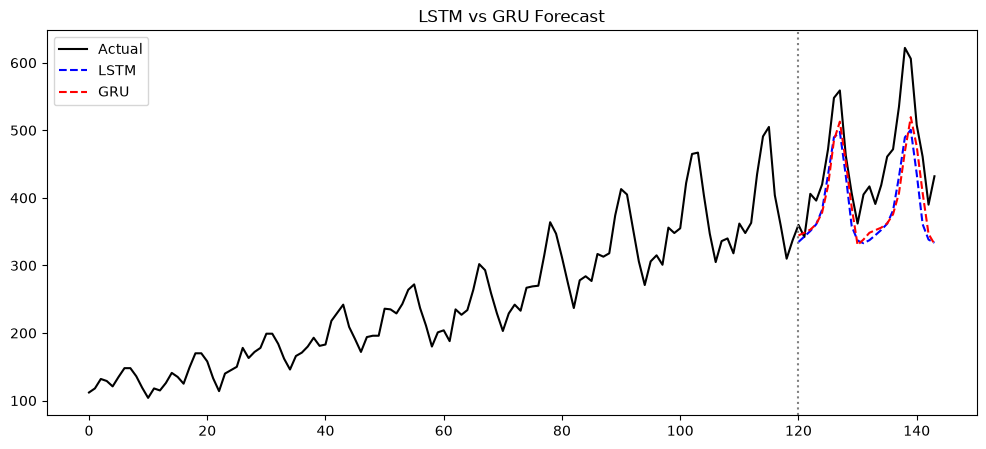

In [3]:
# Recursive forecasting on test set
def forecast_recursive(model, seed_seq, n_steps):
    model.eval()
    preds = []
    seq = torch.FloatTensor(seed_seq).unsqueeze(0).unsqueeze(-1)  # (1, T, 1)
    with torch.no_grad():
        for _ in range(n_steps):
            p = model(seq).item()
            preds.append(p)
            seq = torch.cat([seq[:, 1:, :], torch.FloatTensor([[[p]]])], dim=1)
    return np.array(preds)

seed = series_norm[SPLIT - SEQ_LEN : SPLIT]
n_test = len(series_norm) - SPLIT

lstm_preds = forecast_recursive(lstm_model, seed, n_test) * sigma + mu
gru_preds  = forecast_recursive(gru_model,  seed, n_test) * sigma + mu
actual     = series[SPLIT:]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series, label='Actual', color='black')
ax.plot(range(SPLIT, len(series)), lstm_preds, label='LSTM', linestyle='--', color='blue')
ax.plot(range(SPLIT, len(series)), gru_preds,  label='GRU',  linestyle='--', color='red')
ax.axvline(SPLIT, color='gray', linestyle=':')
ax.set_title('LSTM vs GRU Forecast')
ax.legend()
plt.show()

## Temporal Convolutional Network (TCN)

TCNs use **dilated causal convolutions** to capture long-range dependencies without recurrence.

### Causal convolution
Output at time $t$ depends only on inputs $\leq t$:
$$y_t = \sum_{k=0}^{K-1} w_k \cdot x_{t-k}$$

### Dilated convolution with dilation $d$
Exponentially increases receptive field:
$$y_t = \sum_{k=0}^{K-1} w_k \cdot x_{t - d \cdot k}$$

With $d = 1, 2, 4, 8, \ldots, 2^{L-1}$, receptive field = $2^L \cdot (K-1)$.

**Advantages over LSTM:** fully parallelisable, no sequential dependency, stable gradients.

In [4]:
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               dilation=dilation, padding=padding)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
    
    def forward(self, x):
        out = self.dropout(self.relu(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(self.relu(self.conv2(out)[:, :, :x.size(2)]))
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            in_ch  = input_size if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation=2**i, dropout=dropout))
        self.network = nn.Sequential(*layers)
        self.linear  = nn.Linear(num_channels[-1], output_size)
    
    def forward(self, x):
        # x: (batch, input_size, seq_len)
        y = self.network(x)
        return self.linear(y[:, :, -1])  # last time step


tcn = TCN(input_size=1, output_size=1, num_channels=[16, 32, 64])
print(f"TCN parameters: {sum(p.numel() for p in tcn.parameters()):,}")
print("Receptive field with 3 levels, kernel_size=3:", (3-1)*(2**0 + 2**1 + 2**2))

TCN parameters: 26,833
Receptive field with 3 levels, kernel_size=3: 14


## N-BEATS (Neural Basis Expansion Analysis)

N-BEATS is a pure deep learning model that **requires no feature engineering** and achieves state-of-the-art accuracy on univariate forecasting benchmarks.

### Architecture

N-BEATS uses a **doubly residual** stacking principle with blocks of:

**FC Stack:** $h = \text{FC}(x)$

**Backcast:** $\hat{x} = g_b(h)$ reconstructs input

**Forecast:** $\hat{y} = g_f(h)$ predicts future

**Residual update:**
$$x^{(\ell+1)} = x^{(\ell)} - \hat{x}^{(\ell)}$$
$$\hat{y} = \sum_{\ell} \hat{y}^{(\ell)}$$

Two variants of basis functions $g_b, g_f$:
- **Generic:** learned fully-connected
- **Interpretable:** polynomial (trend) + Fourier (seasonality)

For trend block ($\theta$ = polynomial coefficients):
$$\hat{y} = \sum_{p=0}^{P} \theta_p t^p$$

For seasonality block ($\theta$ = Fourier coefficients):
$$\hat{y} = \sum_{k=1}^{\lfloor H/2 \rfloor} \left(\theta_k^{(c)} \cos\left(\frac{2\pi k t}{H}\right) + \theta_k^{(s)} \sin\left(\frac{2\pi k t}{H}\right)\right)$$

In [5]:
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NBEATS, NHITS
    print("neuralforecast available N-BEATS and N-HiTS ready")
except ImportError:
    print("Install: pip install neuralforecast")
    print("N-BEATS paper: https://arxiv.org/abs/1905.10437")
    print("N-HiTS paper:  https://arxiv.org/abs/2201.12886")

Install: pip install neuralforecast
N-BEATS paper: https://arxiv.org/abs/1905.10437
N-HiTS paper:  https://arxiv.org/abs/2201.12886


## Temporal Fusion Transformer (TFT)

TFT is a **multi-horizon**, **multi-variate** forecasting model combining:
1. **LSTM encoder** for local processing
2. **Variable Selection Networks** identifies important features at each timestep
3. **Gated Residual Networks (GRN)** flexible non-linear processing with skip connections
4. **Temporal Self-Attention** captures long-range dependencies
5. **Quantile outputs** probabilistic forecasts at multiple quantiles

### Gated Residual Network (GRN):
$$\text{GRN}(a, c) = \text{LayerNorm}(a + \text{GLU}(\eta_1))$$
$$\eta_1 = W_1 \eta_2 + b_1$$
$$\eta_2 = \text{ELU}(W_2 a + W_3 c + b_2)$$

where $\text{GLU}(x) = x \odot \sigma(\text{FC}(x))$ is a Gated Linear Unit.

In [6]:
try:
    from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
    print("pytorch-forecasting available TFT ready")
    print("TFT paper: https://arxiv.org/abs/1912.09363")
except ImportError:
    print("Install: pip install pytorch-forecasting")
    print("TFT paper: https://arxiv.org/abs/1912.09363")

Install: pip install pytorch-forecasting
TFT paper: https://arxiv.org/abs/1912.09363


## PatchTST

PatchTST (2023) applies Vision Transformer ideas to time series by treating **patches** (subsequences) as tokens:

1. **Patching:** divide input of length $L$ into patches of length $P$ with stride $S$ → $N = \lfloor(L-P)/S\rfloor + 2$ tokens
2. **Channel independence:** each variable treated as a separate 1D series
3. **Transformer encoder** on patches
4. **Flat head** for forecasting

**Advantage:** reduces sequence length $O(L) \to O(L/P)$, enabling attention over much longer histories.

$$\text{PatchTST paper: https://arxiv.org/abs/2211.14730}$$

## Training Tips for DL Forecasting

```python
# 1. Always normalise per-series or global normalisation
# 2. Gradient clipping prevents exploding gradients in RNNs
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

# 3. Learning rate scheduling
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# 4. Early stopping monitor validation loss
# 5. Batch normalisation or Layer normalisation
# 6. Residual connections help with deep networks
# 7. Dropout regularisation
```

---

## Additional Learning Resources

### Papers
- **N-BEATS** Neural basis expansion analysis: https://arxiv.org/abs/1905.10437
- **N-HiTS** Neural hierarchical interpolation: https://arxiv.org/abs/2201.12886
- **TFT** Temporal Fusion Transformer: https://arxiv.org/abs/1912.09363
- **PatchTST** Patched Transformer for TS: https://arxiv.org/abs/2211.14730
- **TimesNet** Temporal 2D-variation modeling: https://arxiv.org/abs/2210.02186
- **Informer** Efficient Transformer: https://arxiv.org/abs/2012.07436
- **Autoformer** Decomposition Transformer: https://arxiv.org/abs/2106.13008
- **TCN** Empirical evaluation: https://arxiv.org/abs/1803.01271

### Libraries
- NeuralForecast (Nixtla): https://nixtlaverse.nixtla.io/neuralforecast/
- pytorch-forecasting: https://pytorch-forecasting.readthedocs.io/
- GluonTS (Amazon): https://ts.gluon.ai/stable/
- Darts: https://unit8co.github.io/darts/

### Videos
- Andrej Karpathy LSTM explained: https://www.youtube.com/watch?v=iX5V1WpxxkY
- Yannic Kilcher TFT paper review: https://www.youtube.com/watch?v=NbRcMgxw6XE